.

In [106]:
#imports 
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import h5py

from src.evaluate import detect_spikes, score_detections
from scipy.signal import correlate, find_peaks
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score

path = r"C:\spike-denoising-synthetic\data\real"
sample_rate = 30000

print("setup ok")

setup ok


In [3]:
#Load the ground truth
gt = h5py.File(path + r"\grouped_unit_1.mat", "r")
print("top-level fields:", [k for k in gt.keys() if not k.startswith("#")])
zc_ch19 = gt["CH19"]["aligned_zc_locs"][:].flatten()

print("Spikes on CH19:", len(zc_ch19))
print("time range (s): %.1f to %.1f" % (zc_ch19.min(), zc_ch19.max()))

top-level fields: ['CH10', 'CH14', 'CH19', 'CH25', 'CH3', 'CH30', 'CH9', 'filename', 'group_number', 'primary_channel']
Spikes on CH19: 1623
time range (s): 1754.5 to 8265.2


the analysis window begins at index 900 of TTLs_2.bin (t = 3602.67 s); the phase table's TTL numbering implies a start ~70 s earlier, so the file's own indexing was used as it shares a time base with the recording and ground truth.

In [8]:
# Define the window
ttls = np.fromfile(path + r"\TTLs_2.bin", dtype='<f8')

print("number of TTLs:", len(ttls))
print("spacing (s):", np.diff(ttls[:5]))

# MATLAB counts from 1, PYTHON from 0
print("ttls[792]:", ttls[792])  #phase 1 start TTLs from the Table
print("ttls[900]:", ttls[900]) # 900th electricl stimulus pulse

t_start = ttls[900]      # 3602.67 s:TTL index 900 in TTLs_2.bin
t_end   = t_start + 300

print("window: %.2f to %.2f s" % (t_start, t_end))
print("stimuli in window:", ((ttls >= t_start) & (ttls <= t_end)).sum())

number of TTLs: 2310
spacing (s): [4.0007     4.0007     4.00073333 4.0007    ]
ttls[792]: 3170.5945666666667
ttls[900]: 3602.6708
window: 3602.67 to 3902.67 s
stimuli in window: 75


In [14]:
# Load CH19 for that window
n_samples = int(300 * sample_rate)
ch19 = np.fromfile(ch19_file, dtype='<f8', count=n_samples, offset=start_idx * 8)

t_end = t_start + len(ch19) / sample_rate     # from the data, not assumed

noise_mad = np.median(np.abs(ch19)) / 0.6745
gt_in_win = zc_ch19[(zc_ch19 >= t_start) & (zc_ch19 <= t_end)]

print("samples loaded:", len(ch19))
print("seconds: %.1f" % (len(ch19) / sample_rate))
print("noise (MAD): %.2f" % noise_mad)
print("ground-truth spikes in window:", len(gt_in_win))

samples loaded: 9000000
seconds: 300.0
noise (MAD): 4.94
ground-truth spikes in window: 71


In [17]:
# Characterise the spikes: for each ground truth spike time in the window, convert to a sample index

half = 45  #1.5 ms at 30 kHz

depths = []
for st in gt_in_win:
    i = int((st - t_start) * sample_rate)  # index within the loaded window 
    seg = ch19[i - half : i + half]
    if len(seg) == 2 * half:
        depths.append(seg.min())
depths = np.array(depths)
ratios = depths / noise_mad

print("spikes measured:", len(depths))
print("median depth: %.2f (%.2f \ noise)" % (np.median(depths), np.median(ratios)))
print("5th percentile:  %.2f x noise" % np.percentile(ratios, 5))
print("95th percentile: %.2f x noise" % np.percentile(ratios, 95))

spikes measured: 71
median depth: -11.32 (-2.29 \ noise)
5th percentile:  -3.51 x noise
95th percentile: -1.45 x noise


In [20]:
# threshold detection 
print(f"{'k':>5s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for k in [1.5, 2, 2.5, 3, 4]:
    det = detect_spikes(ch19, sample_rate, k=k) + t_start
    precision, recall, f1 = score_detections(det, gt_in_win, tolerance=0.002) 
    print(f"{k:5.1f} {len(det):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")

    k  detected  precision   recall      F1
  1.5     76540     0.0008    0.887   0.002
  2.0     57028     0.0009    0.718   0.002
  2.5     33923     0.0009    0.451   0.002
  3.0     17456     0.0010    0.254   0.002
  4.0      5219     0.0008    0.056   0.002


In [21]:
# Build the template
half   = 45      # 1.5 ms template width
search = 30      # 1 ms how far to look for the true trough

segs = []
for st in gt_in_win:
    i = int((st - t_start) * sample_rate)
    lo, hi = i - half - search, i + half + search
    if lo < 0 or hi > len(ch19):
        continue
    wide   = ch19[lo:hi]
    centre = half + search
    trough = np.argmin(wide[centre - search : centre + search]) + (centre - search)
    seg    = wide[trough - half : trough + half]
    if len(seg) == 2 * half:
        segs.append(seg)

segs = np.array(segs)
template = segs.mean(axis=0)

print("spikes averaged:", len(segs))
print("template trough: %.2f" % template.min())
print("trough / noise:  %.2f" % (template.min() / noise_mad))

spikes averaged: 71
template trough: -11.31
trough / noise:  -2.29


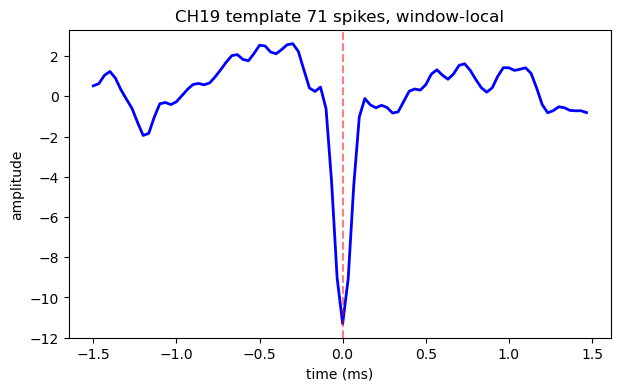

In [22]:
t_ms = (np.arange(2 * half) - half) / sample_rate * 1000
plt.figure(figsize=(7, 4))
plt.plot(t_ms, template, 'b', linewidth=2)
plt.axvline(0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('time (ms)'); plt.ylabel('amplitude')
plt.title('CH19 template %d spikes, window-local' % len(segs))
plt.show()

In [29]:
# template matching
from scipy.ndimage import uniform_filter1d

def template_match(signal, template):
    t = template - template.mean()
    t = t / np.linalg.norm(t)
    n = len(t)
    num = correlate(signal, t, mode='same')
    m   = uniform_filter1d(signal,    n, mode='nearest')
    m2  = uniform_filter1d(signal**2, n, mode='nearest')
    var = np.maximum(m2 - m**2, 0)
    denom = np.sqrt(var * n)
    return np.divide(num, denom, out=np.zeros_like(num), where=denom > 1e-6)

scores = template_match(ch19, template)
print("score range: %.3f to %.3f" % (scores.min(), scores.max()))
print("zeroed samples:", (scores == 0).sum())

score range: -0.824 to 0.865
zeroed samples: 480


In [30]:
print(f"{'thresh':>7s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    peaks, _ = find_peaks(scores, height=th, distance=90)
    det = peaks / sample_rate + t_start
    precision, recall, f1 = score_detections(det, gt_in_win, tolerance=0.002)
    print(f"{th:7.1f} {len(peaks):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")

 thresh  detected  precision   recall      F1
    0.3     64183     0.0009    0.775   0.002
    0.4     49626     0.0009    0.662   0.002
    0.5     26248     0.0012    0.451   0.002
    0.6      8709     0.0014    0.169   0.003
    0.7      1664     0.0018    0.042   0.003


In [34]:
gt_scores = []
for st in gt_in_win:
    i = int((st - t_start) * sample_rate)
    if 90 < i < len(scores) - 90:
        gt_scores.append(scores[i-90:i+90].max())
gt_scores = np.array(gt_scores)

peaks, _ = find_peaks(scores, height=0.3, distance=90)
print("true spikes- median score: %.3f, 5th: %.3f, 95th: %.3f"
      % (np.median(gt_scores), np.percentile(gt_scores,5), np.percentile(gt_scores,95)))
print("all peaks- median score: %.3f, 95th: %.3f"
      % (np.median(scores[peaks]), np.percentile(scores[peaks],95)))

true spikes- median score: 0.519, 5th: 0.408, 95th: 0.707
all peaks- median score: 0.475, 95th: 0.666


In [35]:
# The latency constraint following Troglio et al. (2026)
def in_latency_window(times, ttls, lat_min=0.085, lat_max=0.160):
    idx = np.searchsorted(ttls, times) - 1
    has_ttl = idx >= 0
    latency = np.full(len(times), np.inf)
    latency[has_ttl] = times[has_ttl] - ttls[idx[has_ttl]]
    return (latency >= lat_min) & (latency <= lat_max)

In [36]:
# Sweep
print(f"{'thresh':>7s} {'raw':>8s} {'kept':>6s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    peaks, _ = find_peaks(scores, height=th, distance=90)
    det = peaks / sample_rate + t_start
    det_c = det[in_latency_window(det, ttls)]
    precision, recall, f1 = score_detections(det_c, gt_in_win, tolerance=0.002)
    print(f"{th:7.1f} {len(det):8d} {len(det_c):6d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")


 thresh      raw   kept  precision   recall      F1
    0.3    64183   1193     0.0461    0.775   0.087
    0.4    49626    948     0.0496    0.662   0.092
    0.5    26248    495     0.0646    0.451   0.113
    0.6     8709    172     0.0698    0.169   0.099
    0.7     1664     30     0.1000    0.042   0.059


In [38]:
# Results table for single-contact standard pipeline
results = pd.DataFrame([
    {"Method": "threshold (depth)",        "best F1": 0.002, "precision": 0.0009, "recall": 0.887, "detections": 76540},
    {"Method": "template matching (shape)", "best F1": 0.003, "precision": 0.0018, "recall": 0.042, "detections": 1664},
    {"Method": "template + latency",        "best F1": 0.113, "precision": 0.0646, "recall": 0.451, "detections": 495},
])
results

,Method,best F1,precision,recall,detections
0,threshold (depth),0.002,0.0009,0.887,76540
1,template matching (shape),0.003,0.0018,0.042,1664
2,template + latency,0.113,0.0646,0.451,495


In [39]:
import pandas as pd

results = pd.DataFrame([
    {"Method": "threshold (depth)",         "detections": 76540, "precision": 0.0009, "recall": 0.887, "F1": 0.002},
    {"Method": "template matching (shape)", "detections": 26248, "precision": 0.0012, "recall": 0.451, "F1": 0.002},
    {"Method": "template + latency",        "detections":   495, "precision": 0.0646, "recall": 0.451, "F1": 0.113},
])
results

,Method,detections,precision,recall,F1
0,threshold (depth),76540,0.0009,0.887,0.002
1,template matching (shape),26248,0.0012,0.451,0.002
2,template + latency,495,0.0646,0.451,0.113


# Single-contact detection conclusion
Three detection strategies were tested on CH19 from the real data, scored against the ground truth spikes for one unit:
- Threshold (depth): precision was 0.001. No k works: the unit's spikes span 1.2-5.2x the noise, so any threshold deep enough to reject the noise also rejects the shallow spikes.
- Template matching (shape): precision was around 0.002, which is also not good. This is because the match scores of true spikes (median 0.52) and of all high-scoring peaks (median 0.48) overlap, so no threshold separates them. The high-scoring peaks are other fibres with similar waveforms.
- Template + latency constraint: precision rises 25-50x to 0.05-0.10 by restricting detections to the 85-160 ms post-stimulus window. This is the strongest single-channel result so far, but the best precision is still misclassifies 9 of 10 detections and sacrifices recall.

All detectors fail because a single contact cannot determine which fibre a spike-shaped, correctly timed deflection belongs to. The latency-constrained matcher works as a candidate generator; at a low threshold it retains most of true spikes while discarding around 90% of the search space, but rejecting the surviving spikes from other nerve fibres requires more information than one channel. The spatial fingerprint across contacts (multi-channel), the classifiers for Troglio et al, or denoising to sharpen the waveforms. This motivates the next stages.

# Wavelet on Ch19 single contact 

In [44]:
from src.denoisers import denoise_wavelet_channel

ch19_wav = denoise_wavelet_channel(ch19)
print("original MAD:", np.median(np.abs(ch19)) / 0.6745)
print("denoised MAD:", np.median(np.abs(ch19_wav)) / 0.6745)

original MAD: 4.940607499725379
denoised MAD: 3.1998030435268485


In [46]:
print(f"{'k':>5s} {'detected':>9s} {'precision':>10s} {'recall':>8} {'F1':>7s}")
for k in [1.5, 2, 2.5, 3, 4]:
    det = detect_spikes(ch19_wav, sample_rate, k=k) + t_start
    precision, recall, f1 = score_detections(det, gt_in_win, tolerance=0.002)
    print(f"{k:5.1f} {len(det):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")

    k  detected  precision   recall      F1
  1.5     67816     0.0008    0.789   0.002
  2.0     50749     0.0009    0.676   0.002
  2.5     33688     0.0008    0.394   0.002
  3.0     21131     0.0010    0.296   0.002
  4.0      8785     0.0006    0.070   0.001


### Wavelet results: it made no difference 
. Precision is 0.0008 vs raw 0.0009; recall is slightly worse at low k (0.789 vs 0.887. it looks like wavelet smoothed away some shallow spikes along with the noise. 
would Autoencoder make any difference on single-contact?

# simple dense PyTorch denoising autoencoder (ch19 single-contact)
window=60: input size, 60 samples = 2 ms at 30 kHz, matching the spike template width
encoder: squeezes 60 -> 30 -> 15. The 15 is the bottleneck: too little room to store the noise, so it's forced to keep only the spike structure
decoder expands 15 -> 30 -> 60, rebuilding the full window
No activation on the final layer; the output is a voltage (can be negative), so it must be left linear; a ReLU there would clip everything below zero

In [48]:
import torch 
import torch.nn as nn
print(torch.__version__)
print("CUDA:", torch.cuda.is_available())

2.11.0+cpu
CUDA: False


In [49]:
class DenseDAE(nn.Module):
    def __init__(self, window=60, hidden=15):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(window, 30),
            nn.ReLU(),
            nn.Linear(30, hidden),      
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden, 30),
            nn.ReLU(),
            nn.Linear(30, window),     
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = DenseDAE(window=60, hidden=15)
print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))
        

DenseDAE(
  (encoder): Sequential(
    (0): Linear(in_features=60, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=15, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=15, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=60, bias=True)
  )
)
parameters: 4635


In [64]:
# Train on synthetic data
def make_training_pairs(n=40000, window=60, jitter=8, spike_frac=0.5, seed=0):
    rng = np.random.default_rng(seed)

    t = np.arange(window) - window // 2
    trough  = -np.exp(-(t**2) / (2 * 3.0**2))
    rebound = 0.3 * np.exp(-((t - 6)**2) / (2 * 5.0**2))
    base = trough + rebound
    base = base / np.abs(base.min())          

    clean = np.zeros((n, window))
    for i in range(n):
        if rng.random() < spike_frac:          
            shift = rng.integers(-jitter, jitter + 1)
            amp   = rng.uniform(0.5, 1.5)      
            clean[i] = np.roll(base, shift) * amp
        # else: leave it as zeros — a noise-only window

    noise_std = rng.uniform(0.1, 0.5, size=(n, 1))   # vary noise per window
    noisy = clean + rng.normal(0, 1, size=clean.shape) * noise_std

    return (torch.tensor(noisy, dtype=torch.float32),
            torch.tensor(clean, dtype=torch.float32))

In [65]:
# Trainng loop
X_train, y_train = make_training_pairs()

model = DenseDAE(window=60, hidden=15)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_mse = nn.MSELoss()
dataset = torch.utils.data.TensorDataset(X_train, y_train)
loader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=True)

for epoch in range(30):
    total = 0
    for noisy_batch, clean_batch in loader:
        optimizer.zero_grad()
        loss = loss_mse(model(noisy_batch), clean_batch)
        loss.backward()
        optimizer.step()
        total += loss.item()
    if epoch % 5 == 0 or epoch == 29:
        print(f"epoch {epoch:2d}  loss {total/len(loader):.4f}")

epoch  0  loss 0.0239
epoch  5  loss 0.0022
epoch 10  loss 0.0020
epoch 15  loss 0.0020
epoch 20  loss 0.0019
epoch 25  loss 0.0019
epoch 29  loss 0.0019


In [75]:
#Run the model on the CH19 real data
def ae_denoise_signal(signal, model, window=60, step=20):
    model.eval()
    out = np.zeros(len(signal))
    counts = np.zeros(len(signal))
    scale = np.median(np.abs(signal)) / 0.6745      

    with torch.no_grad():
        for s in range(0, len(signal) - window, step):
            w = signal[s:s+window]
            if w.std() < 1e-6:
                continue
            w_norm = w / scale                       # global scale, keeps spikes big
            recon = model(torch.tensor(w_norm, dtype=torch.float32)).numpy()
            out[s:s+window]    += recon * scale
            counts[s:s+window] += 1

    counts[counts == 0] = 1
    return out / counts

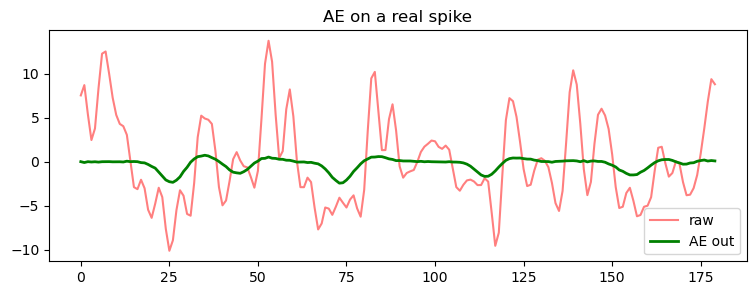

In [80]:
st = gt_in_win[5]
i = int((st - t_start) * sample_rate)
plt.figure(figsize=(9,3))
plt.plot(ch19[i-90:i+90], 'r', alpha=0.5, label='raw')
plt.plot(ch19_ae[i-90:i+90], 'g', linewidth=2, label='AE out')
plt.legend(); plt.title('AE on a real spike'); plt.show()

Training on the synthetic data before real ch19 data did not work. I'm gonna try training on real 

In [84]:
def make_training_pairs_real(n=40000, window=60, jitter=8, spike_frac=0.5, seed=0):
    rng = np.random.default_rng(seed)
    base = template.copy()
    x_old = np.linspace(0, 1, len(base))
    x_new = np.linspace(0, 1, window)
    base = np.interp(x_new, x_old, base)
    base = base / np.abs(base.min())

    clean = np.zeros((n, window))
    for i in range(n):
        if rng.random() < spike_frac:
            shift = rng.integers(-jitter, jitter + 1)
            amp   = rng.uniform(0.5, 3.0)
            clean[i] = np.roll(base, shift) * amp
    noise_std = rng.uniform(0.1, 0.6, size=(n, 1))
    noisy = clean + rng.normal(0, 1, size=clean.shape) * noise_std
    return (torch.tensor(noisy, dtype=torch.float32),
            torch.tensor(clean, dtype=torch.float32))

In [85]:
X_train, y_train = make_training_pairs_real()
model = DenseDAE(window=60, hidden=15)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_mse = nn.MSELoss()
dataset = torch.utils.data.TensorDataset(X_train, y_train)
loader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=True)
for epoch in range(30):
    total = 0
    for nb, cb in loader:
        optimizer.zero_grad()
        loss = loss_mse(model(nb), cb)
        loss.backward(); optimizer.step()
        total += loss.item()
    if epoch % 10 == 0 or epoch == 29:
        print(f"epoch {epoch:2d}  loss {total/len(loader):.4f}")

epoch  0  loss 0.0446
epoch 10  loss 0.0041
epoch 20  loss 0.0035
epoch 29  loss 0.0033


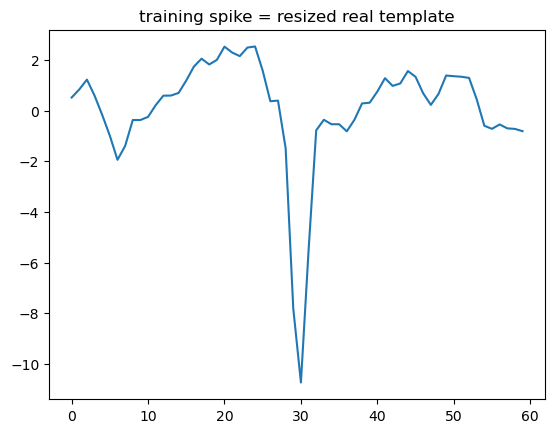

In [86]:
# train on real template 
base = template.copy()
x_old = np.linspace(0, 1, 90)
x_new = np.linspace(0, 1, 60)
base = np.interp(x_new, x_old, base)
plt.plot(base); plt.title('training spike = resized real template'); plt.show()

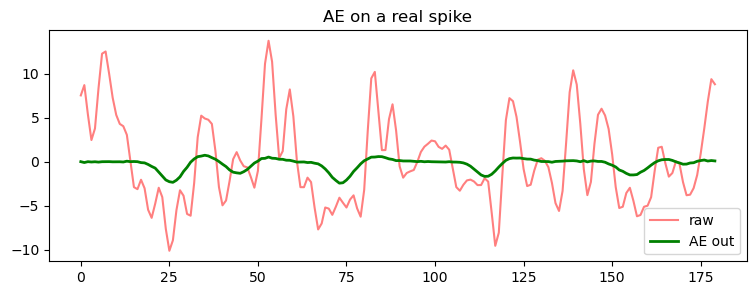

In [87]:
st = gt_in_win[5]
i = int((st - t_start) * sample_rate)
plt.figure(figsize=(9,3))
plt.plot(ch19[i-90:i+90], 'r', alpha=0.5, label='raw')
plt.plot(ch19_ae[i-90:i+90], 'g', linewidth=2, label='AE out')
plt.legend(); plt.title('AE on a real spike'); plt.show()

## Results explination
**to do**

## Troglio et al 2025' alignment method


In [89]:
from scipy.signal import resample
def extract_template_deriv(signal, spike_times, t_start, fs, half=30, search=30, target_len=60):
    """
    Align each spike on the max negative peak of the first derivative. Following Troglio et al. (2025
    """
    segs = [] 
    for st in spike_times:
        i = int((st - t_start) * fs)
        lo, hi = i - half - search, i + half +search
        if lo < 0 or hi > len(signal):
            continue
        wide = signal[lo:hi]
        deriv = np.diff(wide) # first derviative
        center = half + search
        win = deriv[center - search : center + search] 
        align = np.argmin(win) + (center - search)
        seg = wide[align - half : align + half]
        if len(seg) == 2 * half:
            segs.append(seg)
        segs = np.array(segs)
        template = segs.mean(axis=0)
        if len(template) !=target_len:
            template = resample(template, target_len)
        return template, segs
template_deriv, segs_deriv = extract_template_deriv(ch19, gt_in_win, t_start, sample_rate)
print("spikes averaged:", len(segs_deriv))
print("tmplate length:", len(template_deriv))
print("template trough:", template_deriv.min())

spikes averaged: 1
tmplate length: 60
template trough: -14.095593440067038


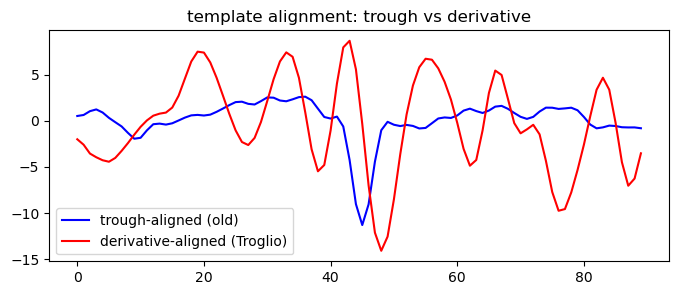

In [92]:
plt.figure(figsize=(8,3))
plt.plot(template, 'b', label='trough-aligned (old)')
plt.plot(resample(template_deriv, len(template)), 'r', label='derivative-aligned (Troglio)')
plt.legend(); plt.title('template alignment: trough vs derivative'); plt.show()

In [93]:
# Does Troglio et al. (2025) derivative alignment template improve detection? 
scores_deriv = template_match(ch19, template_deriv)
print("score range: %.3f to %.3f" % (scores_deriv.min(), scores_deriv.max()))
print(f"\n{'thresh range':>7s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    peaks, _ = find_peaks(scores_deriv, height=th, distance=90)
    det = peaks / sample_rate + t_start
    precision, recall, f1 = score_detections(det, gt_in_win, tolerance=0.002)
    print(f"{th:7.1f} {len(peaks):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")
    

score range: -0.854 to 1.000

thresh range  detected  precision   recall      F1
    0.3     66848     0.0010    0.901   0.002
    0.4     52888     0.0010    0.718   0.002
    0.5     23919     0.0011    0.366   0.002
    0.6      4173     0.0005    0.028   0.001
    0.7       278     0.0036    0.014   0.006


In [94]:
gt_scores = []
for st in gt_in_win:
    i = int((st - t_start) * sample_rate)
    if 90 < i < len(scores_deriv) - 90:
        gt_scores.append(scores_deriv[i-90:i+90].max())
gt_scores = np.array(gt_scores)

peaks, _ = find_peaks(scores_deriv, height=0.3, distance=90)
print("true spikes  — median %.3f, 5th %.3f, 95th %.3f"
      % (np.median(gt_scores), np.percentile(gt_scores,5), np.percentile(gt_scores,95)))
print("all peaks    — median %.3f, 95th %.3f"
      % (np.median(scores_deriv[peaks]), np.percentile(scores_deriv[peaks],95)))

true spikes  — median 0.491, 5th 0.401, 95th 0.577
all peaks    — median 0.469, 95th 0.610


In [104]:
# candidates = template-match peaks that survive the latency window, at threshold 0.3
peaks, _ = find_peaks(scores_deriv, height=0.3, distance=90)
candidate_times = peaks / sample_rate + t_start
candidate_times = candidate_times[in_latency_window(candidate_times, ttls)]

# label each candidate: 1 if within ±2 ms of a ground-truth spike, else 0
def label_candidates(candidate, truth, tol=0.002):
    y = np.zeros(len(candidate), dtype=int)
    for i, t in enumerate(candidate):
        if np.any(np.abs(truth - t) <= tol):
            y[i] = 1
    return y

y = label_candidates(candidate_times, gt_in_win)

print("candidates:", len(candidate_times))
print("true (label 1):", y.sum(), " impostor (label 0):", (y == 0).sum())

candidates: 1241
true (label 1): 68  impostor (label 0): 1173


In [105]:
# extract the 60 sample waveform fro each candidate 
def candidate_waveforms(candidate_times, signal, t_start, fs, half=30):
    X = [] 
    keep = []
    for i, t in enumerate(candidate_times):
        idx = int((t - t_start) * fs)
        seg = signal[idx - half : idx + half]
        if len(seg) == 2 * half:
            X.append(seg)
            keep.append(i)
    return np.array(X), np.array(keep)
X, keep = candidate_waveforms(candidate_times, ch19, t_start, sample_rate)
y_kept = y[keep]  # the keep labels aligned with the waveforms that survived edge triming 
print("X shape:", X.shape)
print("labels:", y_kept.sum(), "true,", (y_kept == 0).sum(), "spikes from other fibres")

X shape: (1241, 60)
labels: 68 true, 1173 spikes from other fibres


In [107]:
# Train and evaluate with 5 fold cross validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = np.zeros(len(y_kept), dtype=int)

for train_idx, test_idx in skf.split(X, y_kept):
    scaler = StandardScaler().fit(X[train_idx])
    clf = SVC(kernel='rbf', class_weight='balanced', random_state=42)
    clf.fit(scaler.transform(X[train_idx]), y_kept[train_idx])
    y_pred[test_idx] = clf.predict(scaler.transform(X[test_idx]))

tp = ((y_pred == 1) & (y_kept == 1)).sum()
fp = ((y_pred == 1) & (y_kept == 0)).sum()
fn = ((y_pred == 0) & (y_kept == 1)).sum()

print(f"predicted true: {(y_pred==1).sum()}  (of {len(y_pred)} candidates)")
print(f"TP {tp}  FP {fp}  FN {fn}")
print(f"precision {precision_score(y_kept, y_pred):.3f}")
print(f"recall    {recall_score(y_kept, y_pred):.3f}")
print(f"F1        {f1_score(y_kept, y_pred):.3f}")

predicted true: 76  (of 1241 candidates)
TP 1  FP 75  FN 67
precision 0.013
recall    0.015
F1        0.014


In [108]:
i = int((gt_in_win[5] - t_start) * sample_rate)
seg = ch19[i-30:i+30]
print("spike points", "DOWN" if abs(seg.min()) > abs(seg.max()) else "UP — check polarity")

spike points UP — check polarity
